# RecycleVision- Garbage Image Classification Using Deep Learning - Data preprocessing

#### Imports

In [4]:
from helper_functions.data_loading.data_utils import get_dataloaders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets

In [3]:
DATA_DIR = "dataset/garbage_classification" 

In [ ]:
  # <- set your real path
tr, va, te, names, weights = get_dataloaders(DATA_DIR)

print("classes:", names)
print("train batches:", len(tr), "| val:", len(va), "| test:", len(te))
print("weights:", weights)

classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
train batches: 340 | val: 73 | test: 73
weights: tensor([1.3690, 1.3134, 2.1292, 1.4525, 0.2428, 2.0520, 1.6789, 1.2312, 1.4957,
        0.6543, 1.8543, 1.6665])


In [ ]:

dataset = datasets.ImageFolder(DATA_DIR)   # no transform = PIL images, good for viewing
class_names = dataset.classes
print(len(dataset), "images,", len(class_names), "classes")

15515 images, 12 classes


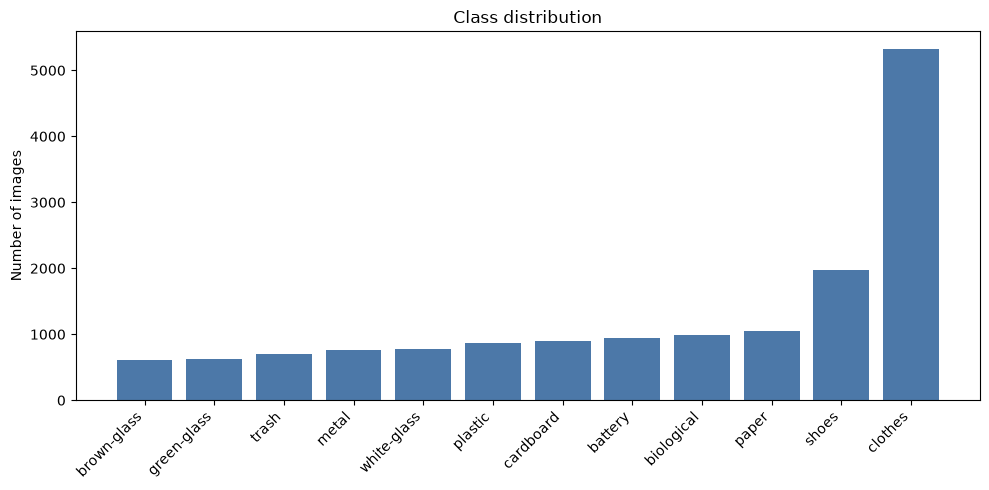

In [7]:
counts = Counter(lab for _, lab in dataset.samples)
counts = {class_names[i]: counts[i] for i in range(len(class_names))}
counts = dict(sorted(counts.items(), key=lambda x: x[1]))

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color="#4C78A8")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

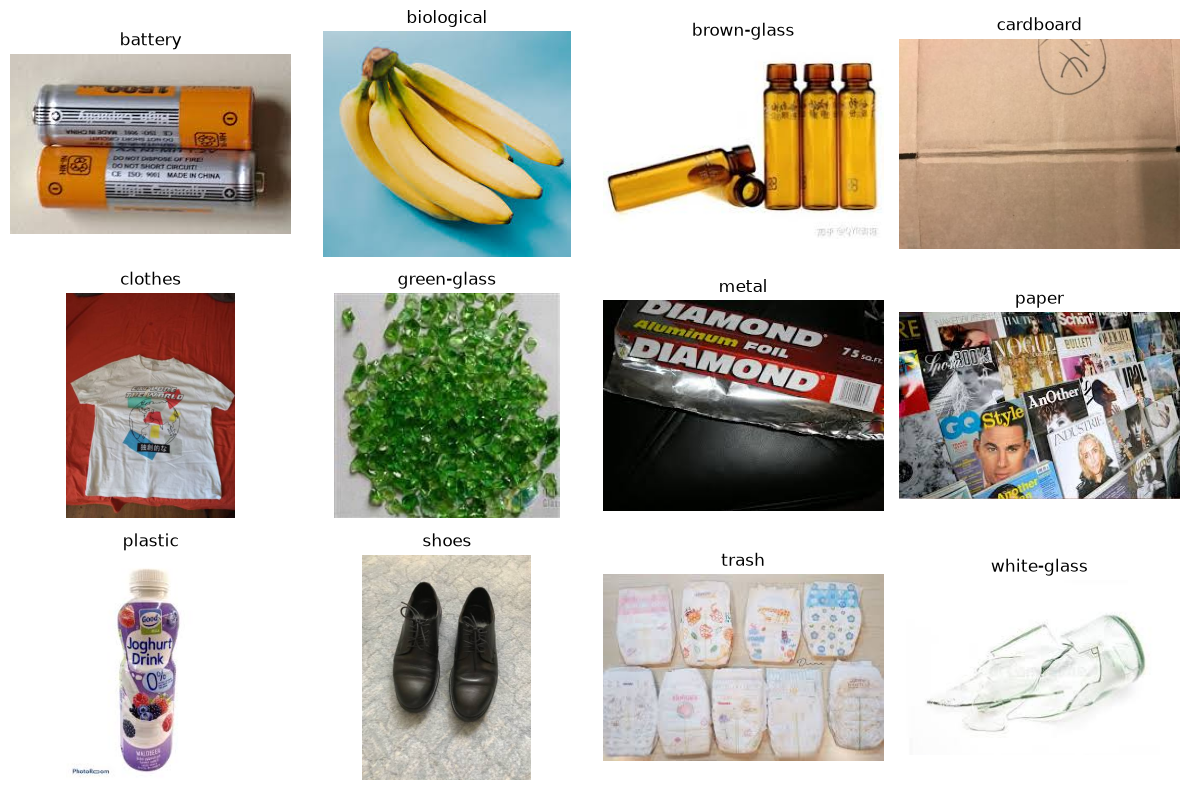

In [10]:
plt.figure(figsize=(12, 8))
for i, cname in enumerate(class_names):
    idx = next(j for j, (_, lab) in enumerate(dataset.samples) if lab == i)
    img, _ = dataset[idx]
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(cname)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
sizes = []
for path, _ in random.sample(dataset.samples, 200):
    with Image.open(path) as im:
        sizes.append(im.size)   # (width, height)
ws = [s[0] for s in sizes]; hs = [s[1] for s in sizes]
print("width  min/max/avg:", min(ws), max(ws), sum(ws) // len(ws))
print("height min/max/avg:", min(hs), max(hs), sum(hs) // len(hs))
print("unique sizes in sample:", len(set(sizes)))

width  min/max/avg: 183 711 354
height min/max/avg: 151 711 368
unique sizes in sample: 62
